In [1]:
import os
import torch
import torch.nn as nn
import torchvision
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, stride=1),    # (1, 28, 28) -> (32, 28, 28)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (32, 28, 28) -> (32, 14, 14)
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1),    # (32, 14, 14) -> (64, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (64, 14, 14) -> (64, 7, 7)
            nn.ReLU(),
        )

        self.mu_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
        self.logvar_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
    
    def forward(self, img):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)    # (64, 7, 7) -> (1, 64*7*7)

        mu = self.mu_layer(x)
        logvar = self.logvar_layer(x)

        return mu, logvar

In [3]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fcnn_layer = nn.Linear(latent_dim, 64*7*7)    # (1, latent_dim) -> (1, 64*7*7)

        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, padding=1, stride=2),    # (64, 7, 7) -> (32, 14, 14)
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4, padding=1, stride=2),    # (32, 14, 14) -> (3, 28, 28)
            nn.Sigmoid(),
        )
    
    def forward(self, latent):
        x = self.fcnn_layer(latent)
        x = x.view(x.size(0), 64, 7, 7)    # (1, 64*7*7) -> (64, 7, 7)

        img = self.conv_layers(x)
        return img

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    
    def forward(self, img):
        mu, logvar = self.encoder(img)

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        
        out = self.decoder(z)
        return out, mu, logvar

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

latent_dim = 64
vae = VAE(latent_dim)
vae = vae.to(device)
vae_model_path = "task1_results/best_model.pt"
vae.load_state_dict(torch.load(vae_model_path))

Using device cuda


<All keys matched successfully>

In [6]:
# Freezing the VAE parameters
for p in vae.parameters():
    p.requires_grad = False

In [7]:
transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

print(f"Using device {device}")

train_data_raw = torchvision.datasets.MNIST(root="mnist", train=True, download=True, transform=transforms)
test_data_raw = torchvision.datasets.MNIST(root="mnist", train=False, download=True, transform=transforms)

indices = (train_data_raw.targets == 1) | (train_data_raw.targets == 2)
train_data_raw.data = train_data_raw.data[indices]
train_data_raw.targets = train_data_raw.targets[indices]

indices = (test_data_raw.targets == 1) | (test_data_raw.targets == 2)
test_data_raw.data = test_data_raw.data[indices]
test_data_raw.targets = test_data_raw.targets[indices]

# Since we deal only with 1 and 2, we can treat this as binary classification problem
train_data_raw.targets = (train_data_raw.targets == 2).long()
test_data_raw.targets  = (test_data_raw.targets == 2).long()

Using device cuda


In [8]:
batch_size = 64
train_dataloader = DataLoader(train_data_raw, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)
test_dataloader = DataLoader(test_data_raw, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

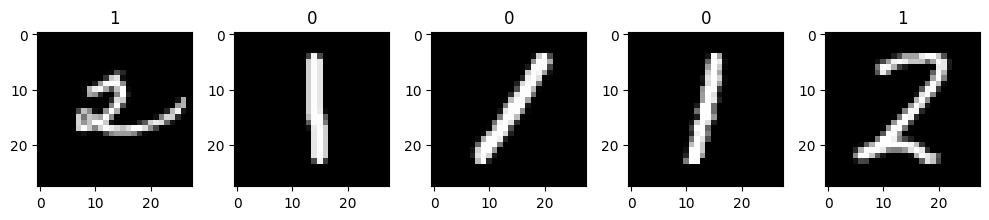

In [9]:
vae.eval()
with torch.no_grad():
    for img, label in train_dataloader:
        # print(img.shape)
        # print(label)

        fig, axes = plt.subplots(1, 5, figsize=(10, 12))
        for i in range(5):
            axes[i].imshow(img[i].squeeze(0), cmap="gray")
            axes[i].set_title(label[i].item())

        plt.tight_layout()
        plt.show()
        break

In [10]:
class Oracle(nn.Module):
    """ 
    This MLP is used as an oracle which takes in the latent embeddings and output the logits for each digits (only 1 here since we deal only with 1 and 2)
    """
    def __init__(self, latent_dim):
        super().__init__()

        self.mlp_layers = nn.Sequential(
            nn.Linear(latent_dim, 128),    # (1, latent_dim) -> (1, 128)
            nn.ReLU(),

            nn.Linear(128, 128),    # (1, 128) -> (1, 128)
            nn.ReLU(),
            
            nn.Linear(128, 1),    # (1, 128) -> (1, 1)
        )

        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        logits = self.mlp_layers(x)
        z = self.sigmoid(logits)
        
        return z, logits

In [11]:
def train_oracle_one_epoch(model, vae, train_dataloader, test_dataloader, loss_func, optimizer, device):
    train_loss = 0

    model.train()
    vae.eval()
    for img, label in train_dataloader:
        img = img.to(device)
        label = label.to(device)

        img_latent_mu, img_latent_logvar = vae.encoder(img)
        pred, logits = model(img_latent_mu)

        optimizer.zero_grad()
        loss = loss_func(pred, label.unsqueeze(1).float())
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    
    test_loss = 0

    model.eval()
    vae.eval()
    with torch.no_grad():
        for img, label in test_dataloader:
            img = img.to(device)
            label = label.to(device)

            img_latent_mu, img_latent_logvar = vae.encoder(img)
            pred, logits = model(img_latent_mu)

            loss = loss_func(pred, label.unsqueeze(1).float())
            test_loss += loss.item()
    
    train_loss /= len(train_dataloader)   
    test_loss /= len(test_dataloader)  

    return train_loss, test_loss

In [12]:
def visualize(model, vae, test_dataloader, epoch, device):
    sample_in = []
    sample_out = []
    sample_true = []

    all_mu = []
    all_label = []

    model.eval()
    vae.eval()
    with torch.no_grad():
        for img, label in test_dataloader:
            img = img.to(device)
            label = label.to(device)

            img_latent_mu, img_latent_logvar = vae.encoder(img)
            pred, logits = model(img_latent_mu)

            if (len(sample_in) == 0):
                sample_in.append(img)    
                sample_out.append(pred)
                sample_true.append(label)
            
            all_mu.append(img_latent_mu)
            all_label.append(label)
    
    sample_in = torch.cat(sample_in, dim=0)
    sample_out = torch.cat(sample_out, dim=0)
    sample_true = torch.cat(sample_true, dim=0)
    all_mu = torch.cat(all_mu, dim=0)
    all_label = torch.cat(all_label, dim=0)

    all_mu = all_mu.cpu()
    all_label = all_label.cpu()

    pca = PCA(n_components=2)
    all_mu_2d = pca.fit_transform(all_mu.numpy())

    scatter = plt.scatter(all_mu_2d[:,0], all_mu_2d[:,1], c=all_label, cmap="RdBu",s=5)

    x_coords, y_coords = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
    grid_points_2d = torch.tensor(np.stack([x_coords.flatten(), y_coords.flatten()], axis=1)).float().to(device)
    grid_points_latent = torch.tensor(pca.inverse_transform(grid_points_2d.cpu().numpy())).float().to(device)    # Mapping PCA dim to latent dim for model to make predicitons

    with torch.no_grad():
        preds, logits = model(grid_points_latent) 
        grid_preds = preds.cpu().numpy()

    plt.figure(figsize=(8,6))
    plt.contourf(x_coords, y_coords, grid_preds.reshape(100,100), levels=50, cmap="RdBu")
    plt.scatter(all_mu_2d[:,0], all_mu_2d[:,1], c=all_label.numpy(), cmap="RdBu", s=5)
    plt.colorbar()
    plt.savefig(f"task3_results/oracle_contours_epoch_{epoch}.png")
    plt.close()

    fig, axes = plt.subplots(5, 1, figsize=(6, 12))
    for i in range(5):
        axes[i].imshow(sample_in[i].squeeze(0).cpu(), cmap="gray")
        axes[i].set_title(f"Actual: {sample_true[i]} | Pred: {sample_out[i].item():.2f}")
    
    plt.tight_layout()
    plt.savefig(f"task3_results/oracle_output_epoch_{epoch}.png")
    plt.close()


In [13]:
def train_oracle(num_epochs, model, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience):
    train_losses = []
    test_losses = []

    best_test_loss = float("inf")
    patience_count = 0
    for epoch in range(num_epochs):
        train_loss, test_loss = train_oracle_one_epoch(model, vae, train_dataloader, test_dataloader, loss_func, optimizer, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        if (epoch % 10 == 0):
            visualize(model, vae, test_dataloader, epoch, device)
            print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f}")

        if (test_loss < best_test_loss):
            patience_count = 0
            best_test_loss = test_loss
            torch.save(model.state_dict(), "task3_results/best_oracle.pt")
        else:
            patience_count += 1
            if (patience_count >= patience):
                print("Early stopping")
                break

    return train_losses, test_losses

In [14]:
latent_dim = 64
oracle = Oracle(latent_dim)
oracle = oracle.to(device)

summary(oracle, (16, 1, 64))

Layer (type:depth-idx)                   Output Shape              Param #
Oracle                                   [16, 1, 1]                --
├─Sequential: 1-1                        [16, 1, 1]                --
│    └─Linear: 2-1                       [16, 1, 128]              8,320
│    └─ReLU: 2-2                         [16, 1, 128]              --
│    └─Linear: 2-3                       [16, 1, 128]              16,512
│    └─ReLU: 2-4                         [16, 1, 128]              --
│    └─Linear: 2-5                       [16, 1, 1]                129
├─Sigmoid: 1-2                           [16, 1, 1]                --
Total params: 24,961
Trainable params: 24,961
Non-trainable params: 0
Total mult-adds (M): 0.40
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.10
Estimated Total Size (MB): 0.14

Epoch 0 | train_loss: 0.1593 | test_loss: 0.0584
Epoch 10 | train_loss: 0.0033 | test_loss: 0.0027
Epoch 20 | train_loss: 0.0020 | test_loss: 0.0023
Epoch 30 | train_loss: 0.0012 | test_loss: 0.0019
Epoch 40 | train_loss: 0.0008 | test_loss: 0.0018
Epoch 50 | train_loss: 0.0005 | test_loss: 0.0016
Early stopping


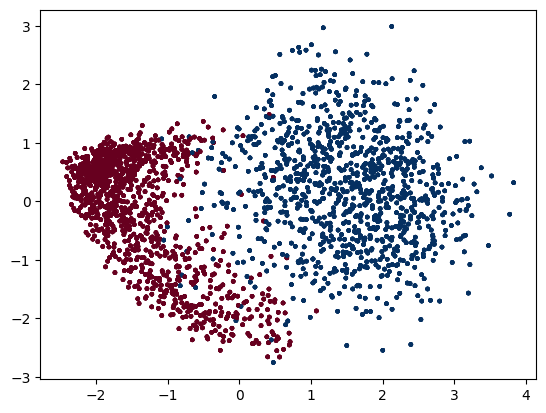

In [15]:
os.makedirs("task3_results", exist_ok=True)
num_epochs = 75
beta = 1
lr = 1e-4
patience = 5
loss_func = nn.MSELoss(reduction="mean")
optimizer = torch.optim.Adam(oracle.parameters(), lr=lr)

train_losses, test_losses = train_oracle(num_epochs, oracle, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience)

In [16]:
latent_dim = 64
oracle = Oracle(latent_dim)
oracle = oracle.to(device)
oracle_model_path = "task3_results/best_oracle.pt"
oracle.load_state_dict(torch.load(oracle_model_path))

<All keys matched successfully>

In [17]:
class SymmetricTransformationMLP(nn.Module):
    def __init__(self, latent_dim, num_transformers):
        super().__init__()
        self.num_transformers = num_transformers
        
        self.transformers = nn.ModuleList()
        for i in range(num_transformers):
            self.transformers.append(nn.Sequential(
                nn.Linear(latent_dim, 128),    # (1, latent_dim) -> (1, 128)
                nn.ReLU(),

                nn.Linear(128, 128),    # (1, 128) -> (1, 128)
                nn.ReLU(),
                
                nn.Linear(128, latent_dim),    # (1, 128) -> (1, latent_dim)
            ))

    def forward(self, x):
        x_transformed_all = []
        for i in range(self.num_transformers):
            x_transformed = self.transformers[i](x)
            x_transformed = x_transformed.unsqueeze(0)    # The additional dimension will hold the concerned generator
            x_transformed_all.append(x_transformed)
        
        x_transformed_all = torch.cat(x_transformed_all, dim=0)
        return x_transformed_all

In [18]:
class SymmeteryLoss(nn.Module):
    """ 
    Symmetery Loss is a combination of 4 losses: Invariance + Infinitesimality, Normalization, Orthogonality and Closure
    """
    def __init__(self, oracle, eps, beta_inv_inf, beta_norm, beta_ortho, beta_closure):
        super().__init__()
        self.oracle = oracle
        self.eps = eps
        self.beta_inv_inf = beta_inv_inf
        self.beta_norm = beta_norm
        self.beta_ortho = beta_ortho
        self.beta_closure = beta_closure

        self.mse_loss = nn.MSELoss(reduction="mean")

    def forward(self, original_input, transformed_input):
        loss_inv_inf = 0
        loss_norm = 0

        with torch.no_grad():
            original_output, original_logits = self.oracle(original_input)

        for i in range(transformed_input.shape[0]):
            transformed_output, transformed_logits = self.oracle(original_input + self.eps*transformed_input[i])    # This term ensures that we are exploring the infinitesimal transforms

            loss_inv_inf += self.mse_loss(transformed_output, original_output) / (self.eps**2)

            norms = torch.norm(transformed_input[i], dim=1)
            loss_norm += ((norms - 1)**2).mean() + norms.std()

        loss_inv_inf /= transformed_input.shape[0]
        loss_norm /= transformed_input.shape[0]
        
        total_loss = self.beta_inv_inf*loss_inv_inf + self.beta_norm*loss_norm

        return total_loss, loss_inv_inf, loss_norm

In [ ]:
def train_one_epoch(generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device):
    train_loss = 0
    train_loss_inv_inf = 0
    train_loss_norm = 0

    generators.train()
    for img, label in tqdm(train_dataloader, desc="Training"):
        img = img.to(device)
        label = label.to(device)

        with torch.no_grad():
            img_latent_mu, img_latent_logvar = vae.encoder(img)
            
        x_transformed_all = generators(img_latent_mu)

        optimizer.zero_grad()
        loss, loss_inv_inf, loss_norm = loss_func(img_latent_mu, x_transformed_all)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loss_inv_inf += loss_inv_inf.item()
        train_loss_norm += loss_norm.item()

    test_loss = 0
    test_loss_inv_inf = 0
    test_loss_norm = 0

    generators.eval()
    for img, label in tqdm(test_dataloader, desc="Validating"):
        img = img.to(device)
        label = label.to(device)

        with torch.no_grad():
            img_latent_mu, img_latent_logvar = vae.encoder(img)
            
        x_transformed_all = generators(img_latent_mu)

        optimizer.zero_grad()
        loss, loss_inv_inf, loss_norm = loss_func(img_latent_mu, x_transformed_all)
        loss.backward()
        optimizer.step()

        test_loss += loss.item()
        test_loss_inv_inf += loss_inv_inf.item()
        test_loss_norm += loss_norm.item()
    
    train_loss /= len(train_dataloader)   
    train_loss_inv_inf /= len(train_dataloader) 
    train_loss_norm /= len(train_dataloader) 
    test_loss /= len(test_dataloader)  
    test_loss_inv_inf /= len(test_dataloader)
    test_loss_norm /= len(test_dataloader)

    return train_loss, train_loss_inv_inf, train_loss_norm, test_loss, test_loss_inv_inf, test_loss_norm

In [ ]:
def train(num_epochs, generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience):
    train_losses = []
    train_losses_inv_inf = []
    train_losses_norm = []
    test_losses = []
    test_losses_inv_inf = []
    test_losses_norm = []

    best_test_loss = float("inf")
    patience_count = 0
    for epoch in range(num_epochs):
        train_loss, train_loss_inv_inf, train_loss_norm, test_loss, test_loss_inv_inf, test_loss_norm = train_one_epoch(generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device)

        train_losses.append(train_loss)
        train_losses_inv_inf.append(train_loss_inv_inf)
        train_losses_norm.append(train_loss_norm)
        test_losses.append(test_loss)
        test_losses_inv_inf.append(test_loss_inv_inf)
        test_losses_norm.append(test_loss_norm)

        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f}")

        if (test_loss < best_test_loss):
            patience_count = 0
            best_test_loss = test_loss
            torch.save(generators.state_dict(), "task3_results/best_generator.pt")
        else:
            patience_count += 1
            if (patience_count >= patience):
                print("Early stopping")
                break

    return train_losses, train_losses_inv_inf, train_losses_norm, test_losses, test_losses_inv_inf, test_losses_norm

In [36]:
# Freezing the oracle parameters
for p in oracle.parameters():
    p.requires_grad = False

In [37]:
oracle = oracle
eps = 1e-4
beta_inv_inf = 1
beta_norm = 1
beta_ortho = 1
beta_closure = 1

loss_func = SymmeteryLoss(oracle, eps, beta_inv_inf, beta_norm, beta_ortho, beta_closure)

In [41]:
num_epochs = 5
latent_dim = 64
num_transformers = 2
lr = 1e-4
generators = SymmetricTransformationMLP(latent_dim, num_transformers)
generators = generators.to(device)
optimizer = torch.optim.Adam(generators.parameters(), lr)

train_losses, train_losses_inv_inf, train_losses_norm, test_losses, test_losses_inv_inf, test_losses_norm = train(num_epochs, generators, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience)

Training:   0%|          | 0/199 [00:00<?, ?it/s]

Validating: 100%|██████████| 34/34 [00:00<00:00, 74.33it/s]


0.6177212474867702
Epoch 0 | train_loss: 0.0568 | test_loss: 0.0185


Validating: 100%|██████████| 34/34 [00:00<00:00, 61.29it/s]


0.33703189343214035
Epoch 1 | train_loss: 0.0133 | test_loss: 0.0101


...

0.23791799461469054
Epoch 2 | train_loss: 0.0083 | test_loss: 0.0071


Validating: 100%|██████████| 34/34 [00:00<00:00, 66.07it/s]


0.18333637807518244
Epoch 3 | train_loss: 0.0061 | test_loss: 0.0055


Validating: 100%|██████████| 34/34 [00:00<00:00, 50.97it/s]

0.14824161166325212
Epoch 4 | train_loss: 0.0048 | test_loss: 0.0045


In [42]:
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("task3_results/total_loss.png")
plt.close()

plt.figure()
plt.plot(train_losses_inv_inf, label="train")
plt.plot(test_losses_inv_inf, label="test")
plt.title("Invariance and Infinitesimal Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("task3_results/inv_inf_loss.png")
plt.close()

plt.figure()
plt.plot(train_losses_norm, label="train")
plt.plot(test_losses_norm, label="test")
plt.title("Norm Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("task3_results/norm_loss.png")
plt.close()